
# Introduction
In this lab, you will explore how a computer can learn to recognize handwritten numbers. You will work through the complete process of building, training, and testing an artificial intelligence model that identifies digits from images.


You will use the MNIST dataset, a classic collection of handwritten digit images, to train a neural network. MNIST provides a clean, well-structured starting point that allows you to focus on learning how AI works rather than struggling with messy data from the start.

MNIST has played an important role in the history of machine learning. It was created to provide a standard way to test and compare learning algorithms. Because the images are small, grayscale, and consistently formatted, MNIST makes it easier to see the core ideas behind image recognition without unnecessary complexity.

During the lab, you will:

* Load and inspect image data from the MNIST dataset
* Learn how images are represented as numbers inside a computer
* Build a neural network model made up of layers
* Train the model using labeled examples
* Evaluate how well the model performs on unseen data
* Test the trained model on your own handwritten digits

The lab concludes by having you test the model on your own handwritten digits. This step highlights an important lesson: models trained on clean, standardized data may struggle when faced with real-world inputs.

##Import - Getting the Tools for Our Kitchen
Think of Python as a kitchen.

When you first walk into the kitchen, you have some basic things available—a counter, a sink, a knife. You can do simple tasks, but you cannot cook a michilen star meal without bringing in special specialized tools.

In Python, the word ```import``` is how we bring those ingredients and tools into the kitchen.

When you see an ```import``` line, you can read it as:

“I am bringing this tool into my kitchen so I can use it later.”

Before we can build our AI we need to get all of our tools ready. Each line below brings in a different tool that we will use at various points in this lab.

* **NumPy** is used for working with numbers and large collections of numbers. We use as np as shorthand so we dont have to type numpy everytime we want to use it.
* **Pandas** is used to work with data arranged in rows and columns, similar to a spreadsheet. We use as pd for shorthand so we don't have to type pandas everythime we want to use it.
* **Matplotlib** lets us create charts and graphs. We use as plt for shorthand so we dont't have to type matplotlib.pyplot everytime we want to use it.

* **sklearn**  This tool helps us split our data into two parts:
  * Training data: what the model learns from
  * Testing data: what we use to see how well it learned

* **tensorflow.keras** This tool was developed by a team at Google. It allows us to build an AI model step by step.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras import callbacks
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.utils import to_categorical

##Training Data - Our Ingredients
Before we can train an AI model, we need training data.
In our kitchen analogy, this data represents the ingredients we will use to cook the final dish (the AI model).

Each row in the data is one example, and each column is a piece of information about that example.

###Where This Data Comes From (Images → Numbers)
For our task, the original data starts as 28 × 28 grayscale images.
Each image is made up of pixels Each pixel is a number representing how dark or light it is. AI models cannot work directly with images — they work with numbers

To make the images usable:
* Each 28 × 28 image is flattened into a single row of numbers
* The result is saved in a CSV file

### What Are `X` and `y`?

In machine learning, we usually split data into two parts:
* **`X`** — the input data (features)
* **`y`** — the correct answers (labels)

```python
X = train_data.iloc[:, 1:]
y = train_data.iloc[:, 0]
```

* `X` contains the **pixel values** of the images
* `y` contains the **correct label** for each image (for example, which number the image represents)

### What Does “Shape” Mean?

```python
print("Shape of train_data:", train_data.shape)
```
The word **shape** describes the **size of the data**.
It tells us:
* How many **rows** (how many examples)
* How many **columns** (how much information per example)

For example:

```
(19999, 785)
```

This would mean:

* 19,999 images
* 785 columns total (1 label + 784 pixel values)


In [4]:
train_data = pd.read_csv('./sample_data/mnist_train_small.csv')
print("Shape of train_data:", train_data.shape)


X = train_data.iloc[:, 1:]
y = train_data.iloc[:, 0]

print("Shape of X after separating features:", X.shape)

Shape of train_data: (19999, 785)
Shape of X after separating features: (19999, 784)


## Data Preprocessing - Washing and Prepping our Ingredients

## Cleaning the Data — Washing and Prepping the Ingredients

Before we cook, we need to make sure our ingredients are **clean, consistent, and ready to use**.
Even though our data came from images, once it is loaded into Python it can still contain issues that would confuse an AI model.

This section prepares the data so the model can learn effectively.

---

### Making Sure the Data Is in the Right Container

```python
if not isinstance(X, pd.DataFrame):
    X = pd.DataFrame(X)
```

* This checks whether `X` is stored as a **Pandas DataFrame**.
* If it is not, we convert it into one.
* This ensures we can use Pandas tools consistently in the next steps.

---

### Ensuring Everything Is Numeric

```python
X = X.apply(pd.to_numeric, errors='coerce')
```

* AI models can only work with **numbers**.
* This line makes sure every value in `X` is numeric.
* If something cannot be converted to a number, it is replaced with a missing value.


---

### Handling Missing Values

```python
X = X.fillna(0)
```

* This replaces any missing values with `0`.
* Missing values can cause errors or unpredictable behavior in models.
* Using `0` is safe here because black pixels in images are represented by zero.

---

### Scaling the Pixel Values

```python
X = X.values / 255.0
```

* Pixel values range from **0 to 255**.
* Dividing by 255 scales everything to a range between **0 and 1**.
* This helps the AI model learn more efficiently.

---

### Reshaping the Data Back Into Images

```python
X = X.reshape(-1, 28, 28, 1)
```

* This reshapes each row of numbers back into a **28 × 28 image**.
* The final `1` represents a single grayscale color channel.
* `-1` tells Python to figure out how many images there are automatically.


In [5]:
if not isinstance(X, pd.DataFrame):
    X = pd.DataFrame(X)
X = X.apply(pd.to_numeric, errors='coerce')
X = X.fillna(0)
X = X.values / 255.0
X = X.reshape(-1, 28, 28, 1)
print("Shape of X after reshaping:", X.shape)

Shape of X after reshaping: (19999, 28, 28, 1)


## Preparing the Labels — Labeling the Finished Dishes

So far, we have prepared the **ingredients** (`X`).
Now we need to prepare the **labels** (`y`), which tell the AI model what each image represents.

---

### Why Labels Need Special Formatting

Originally, `y` contains simple numbers like:

```
0, 1, 2, ..., 9
```

While these numbers make sense to humans, an AI model needs the information presented in a more structured way so it does not assume:

* That “9” is bigger or better than “1”
* That the numbers have a natural order

Instead, we use a format called **one-hot encoding**.

---

### What Is One-Hot Encoding?

```python
y = to_categorical(y, num_classes=10)
```

* This converts each label into a list of 10 values
* Only **one position is “hot” (set to 1)**, and the rest are 0

Example:

* The label `3` becomes

  ```
  [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
  ```

This tells the model:

> “This image belongs to class 3, and no other.”

---

### Why We Do This

* It prevents the model from misinterpreting numeric labels
* It makes classification clearer and more stable
* It matches what neural networks expect during training

---

### Checking the Shape of the Labels

```python
print("Shape of y after one-hot encoding:", y.shape)
```

* This confirms the labels were converted correctly
* The shape will now be:

  * Number of images
  * Number of possible classes (10)


In [6]:
y = to_categorical(y, num_classes=10)
print("Shape of y after one-hot encoding:", y.shape)

Shape of y after one-hot encoding: (19999, 10)


## Splitting the Data — Cooking vs. Taste Testing

Now that our ingredients (`X`) and labels (`y`) are prepared, we need to decide **how we will use them**.

If we let the AI learn from *all* the data and then test it on the *same* data, it would be like:

> Memorizing the answers to a test instead of learning the material

Instead, we split the data into two groups.

---

### Training Data vs. Validation Data

```python
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
```

This line divides the data into:

* **Training data** (`X_train`, `y_train`)

  * Used to teach the model
* **Validation data** (`X_val`, `y_val`)

  * Used to check how well the model learned

Key details:

* `test_size=0.2` means:

  * 80% of the data is used for training
  * 20% is held back for validation
* `random_state=42` ensures:

  * The split is **repeatable**
  * Everyone gets the same results when running the notebook

---

### Why This Step Matters

* It helps us see if the model can handle **new data**
* It prevents the model from simply memorizing
* It gives us a more honest measure of performance

In [7]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train shape:", X_train.shape)

X_train shape: (15999, 28, 28, 1)


## Original Model (Baseline You Will Modify)

In this section we define our first neural network. This is the **baseline model** for the lab. One homework task will ask you to **copy this model, change parts of it, and retrain it** to observe what happens.

### What this code is doing

```python
model = Sequential([
    Input(shape=(28, 28, 1)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])
```

This creates a neural network made of “layers,” in order:

* **`Input(shape=(28, 28, 1))`**
  Tells the model what each input example looks like: a 28×28 grayscale image (the last `1` means one color channel). Do not modify the Input Shape

* **`Flatten()`**
  Converts the 28×28 image into a single long list of numbers so it can be processed by the next layers.
  (28×28 = 784 numbers)

* **`Dense(128, activation='relu')`** and **`Dense(64, activation='relu')`**
  These are the “learning layers.”

  * The numbers (128 and 64) are how many neurons are in each layer.
  * `relu` is a common activation function that helps the model learn complex patterns.

* **`Dense(10, activation='softmax')`**
  The output layer. We have **10 outputs** because there are 10 possible classes (0–9).
  `softmax` produces a probability-like score across the 10 classes.

---

### Compiling the model (choosing how it learns)

```python
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
```

This tells the model how training should work:

* **`optimizer='adam'`**: the strategy the model uses to update itself while learning
* **`loss='categorical_crossentropy'`**: how we measure “how wrong” the model is during training (this is standard for multi-class classification with one-hot labels)
* **`metrics=['accuracy']`**: we also track accuracy so we can see how often the model is correct

---

### Viewing the model

```python
model.summary()
```

This prints a readable “blueprint” of the model, including:

* the layers
* the output shapes
* how many parameters (learnable values) the model has

In [8]:
#Orginal Model
model = Sequential([
    Input(shape=(28, 28, 1)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## Copy, Modify, and Retrain the Model in Google Colab

You will often experiment by creating a modified version of the model in a **new code cell** so you can compare results without losing your original.

### Step 1: Add a new code cell in Google Colab

Use any of these methods:

* Click **`+ Code`** near the top of the notebook, or
* Hover between cells and click the small **`+ Code`** button that appears, or
* Keyboard shortcuts:

  * **Windows/ChromeOS:** `Ctrl + M` then `B` (add cell **below**)
  * **Mac:** `Cmd + M` then `B`

### Step 2: Copy the original model into the new cell

1. Highlight the full model code (the `Sequential([...])`, `compile`, and `summary`)
2. Copy (`Ctrl+C` / `Cmd+C`)
3. Paste into your new code cell (`Ctrl+V` / `Cmd+V`)

### Step 3: Modify the model (examples of allowed changes)

In homework, you may be asked to change **one thing at a time** so you can clearly see what caused the difference.

Common modifications include:

* Change the number of neurons, e.g. `Dense(128)` → `Dense(256)`
* Add another Dense layer, e.g. insert `Dense(32, activation='relu')`
* Remove a layer (simplify the model)
* Change an activation function (for hidden layers), e.g. `'relu'` → `'tanh'`
* Change the optimizer, e.g. `'adam'` → `'sgd'`

Important rule: keep the output layer as:

```python
Dense(10, activation='softmax')
```

because we still have 10 classes.

### Step 4: Recompile after changes

After changing the model architecture, you should rerun:

```python
model.compile(...)
```

Compiling “locks in” the training settings for that model.

### Step 5: Retrain the model

After defining and compiling your modified model, run the **training cell** again (the one that calls `model.fit(...)`).

Typical workflow:

1. Run your modified model cell (creates the new model)
2. Run the training cell (`model.fit(...)`)
3. Run the evaluation/accuracy cell (if your notebook has one)
4. Compare results to the original

### Step 6: Keep your results organized

To avoid confusion:

* Add a comment at the top of your modified cell, for example:

  ```python
  # Model Variant 1: 256 neurons in first Dense layer
  ```

## What You Should Pay Attention To When You Modify It

When you change the model and retrain, look for:

* Does training accuracy improve while validation accuracy gets worse? (possible overfitting)
* Does training become slower or faster?
* Does the model become more or less accurate overall?
* Does the number of parameters in `model.summary()` change a lot?

This is the core skill of model experimentation: make a change, retrain, observe, and explain the results.


In [ ]:
#Orginal Model
# model = Sequential([
#     Input(shape=(28, 28, 1)),
#     Flatten(),
#     Dense(128, activation='relu'),
#     Dense(64, activation='relu'),
#     Dense(10, activation='softmax')
# ])
# model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# model.summary()

#Model Variant 1: 5 hidden layers with 128 neurons each
# model = Sequential([
#     Input(shape=(28, 28, 1)),
#     Flatten(),
#     Dense(128, activation='relu'),
#     Dense(128, activation='relu'),
#     Dense(128, activation='relu'),
#     Dense(128, activation='relu'),
#     Dense(128, activation='relu'),
#     Dense(10, activation='softmax')
# ])
# model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# model.summary()

#Model Variant 2: 5 hidden layers with 256 neurons each
# model = Sequential([
#     Input(shape=(28, 28, 1)),
#     Flatten(),
#     Dense(256, activation='relu'),
#     Dense(256, activation='relu'),
#     Dense(256, activation='relu'),
#     Dense(256, activation='relu'),
#     Dense(256, activation='relu'),
#     Dense(10, activation='softmax')
# ])
# model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# model.summary()

#Model Variant 3: 2 hidden layers with 32 neurons each
# model = Sequential([
#     Input(shape=(28, 28, 1)),
#     Flatten(),
#     Dense(32, activation='relu'),
#     Dense(32, activation='relu'),
#     Dense(10, activation='softmax')
# ])
# model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# model.summary()

#Model Variant 4: 2 hidden layers with 32 neurons each
model = Sequential([
    Input(shape=(28, 28, 1)),
    Flatten(),
    Dense(1024, activation='relu'),
    Dense(1024, activation='relu'),
    Dense(10, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

In [ ]:
history = model.fit(X_train, y_train, epochs=1000, batch_size=32, validation_data=(X_val, y_val))

Epoch 1/1000
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 898us/step - accuracy: 0.7887 - loss: 0.7549 - val_accuracy: 0.9300 - val_loss: 0.2542
Epoch 2/1000
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 759us/step - accuracy: 0.9426 - loss: 0.1930 - val_accuracy: 0.9473 - val_loss: 0.1867
Epoch 3/1000
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 724us/step - accuracy: 0.9647 - loss: 0.1218 - val_accuracy: 0.9570 - val_loss: 0.1476
Epoch 4/1000
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 818us/step - accuracy: 0.9749 - loss: 0.0867 - val_accuracy: 0.9507 - val_loss: 0.1647
Epoch 5/1000
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 745us/step - accuracy: 0.9836 - loss: 0.0597 - val_accuracy: 0.9525 - val_loss: 0.1643
Epoch 6/1000
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 688us/step - accuracy: 0.9869 - loss: 0.0434 - val_accuracy: 0.9532 - val_loss: 0.1580
Epoch 7/1000
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 706us/step - accuracy: 0.9885 - loss: 0.0374 - val_accuracy: 0.9647 - val_loss: 0.1363
Epoch 8/1000
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 768us/step - accuracy: 0.9923 -

## Testing the Model and Viewing Predictions

Once a model has been trained, the next step is to see how it performs on new data it has never seen before. This is a critical part of AI and machine learning: we are no longer teaching the model — we are asking it to make predictions.

---

### Loading the Test Data

```python
test_data = pd.read_csv('test.csv')
```

* This loads the **test dataset** from a CSV file.
* The goal is for the model to predict what each image represents.

---

### Preparing the Test Data

```python
X_test = test_data.values / 255.0
```

* Just like the training data, pixel values range from 0 to 255.
* We divide by 255 so the values fall between 0 and 1.
* The test data must be prepared **the same way** as the training data.

```python
X_test = X_test.reshape(-1, 28, 28, 1)
```

* This reshapes the data back into image form.
* Each image becomes 28 × 28 pixels with 1 grayscale channel.
* The model expects this exact shape.

---

### Making Predictions

```python
predictions = model.predict(X_test)
```

* The model looks at each image and outputs **10 numbers**.
* Each number represents how confident the model is that the image belongs to a certain class (0–9).
* These are not final labels yet — they are **scores**.

---

### Converting Scores Into Final Labels

```python
predicted_labels = np.argmax(predictions, axis=1)
```

* `argmax` finds the index of the **largest value** in each prediction.
* That index corresponds to the predicted digit.
* For example, if the largest value is in position 7, the predicted label is `7`.


---

### Visualizing the Predictions

```python
for i in indices_to_show:
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"Predicted: {predicted_labels[i]} | True: {y_test[i]}")
    plt.axis('off')
    plt.show()
```

This loop displays the first 5 test images along with the model’s prediction.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 397us/step
Overall test accuracy: 0.9662 (96.62%)


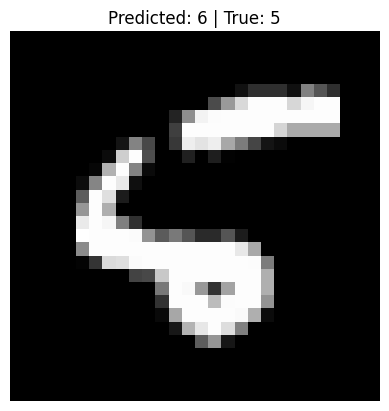

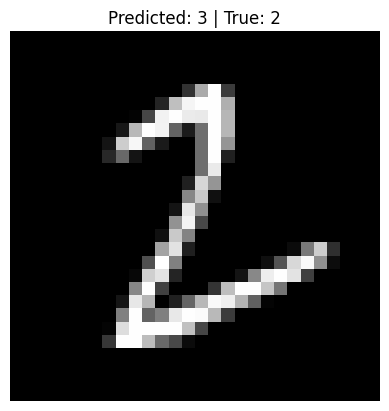

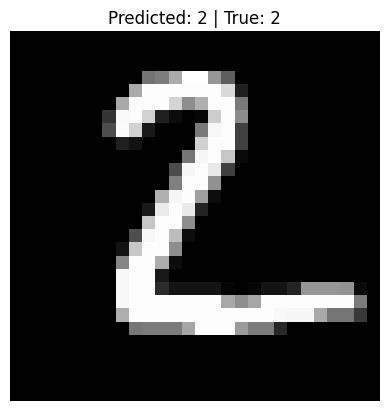

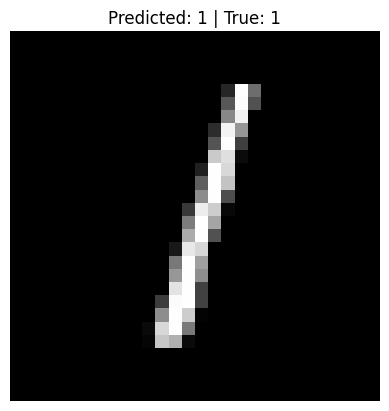

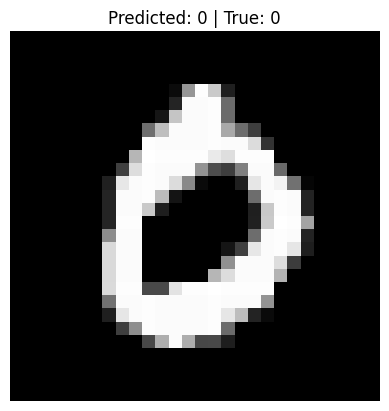

In [ ]:
# Load labeled test data (MNIST-style: first column = label, remaining = pixels)
test_data = pd.read_csv('./sample_data/mnist_test.csv')

y_test = test_data.iloc[:, 0].values
X_test = test_data.iloc[:, 1:].values

# Normalize and reshape to match the model input
X_test = X_test / 255.0
X_test = X_test.reshape(-1, 28, 28, 1)

# Predict
predictions = model.predict(X_test)
predicted_labels = np.argmax(predictions, axis=1)

# Overall accuracy
accuracy = np.mean(predicted_labels == y_test)
print(f"Overall test accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Find misclassified indices (if any)
mis_idx = np.where(predicted_labels != y_test)[0]

# Choose indices to display:
# - If there's at least one mistake, show one misclassified example first
# - Then fill the rest with correctly classified examples
indices_to_show = []

if len(mis_idx) > 0:
    indices_to_show.append(mis_idx[0])
    if len(mis_idx) > 1:
      indices_to_show.append(mis_idx[1])

# Fill remaining slots up to 5 examples
correct_idx = np.where(predicted_labels == y_test)[0]
for idx in correct_idx:
    if len(indices_to_show) >= 5:
        break
    if idx not in indices_to_show:
        indices_to_show.append(idx)

# If there were no correct examples (extremely unlikely), just show first 5
if len(indices_to_show) < 5:
    indices_to_show = list(range(min(5, len(X_test))))

# Display images with predicted and true labels
for i in indices_to_show:
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"Predicted: {predicted_labels[i]} | True: {y_test[i]}")
    plt.axis('off')
    plt.show()


##Upload Images

## Uploading and Testing Your Own Handwritten Digits

In this part of the lab, you will test the trained AI model using your own handwritten digits. Follow the steps carefully to get the best results.

---

### Step 1: Write the Digits

1. Take a blank sheet of white paper.
2. Write one digit at a time (0 through 9).
3. Use a thick pen or Sharpie if possible.

   * Thicker lines work better than thin pencil marks.

Tip: Avoid decorations, boxes, or underlines. Just the digit.


### Step 2: Take a Photo

1. Place the paper on a flat surface.
2. Take a clear photo using your phone or camera.
3. Make sure:

   * The paper fills most of the frame
   * There are no heavy shadows
   * The digit is not blurry

Good lighting makes a big difference.

### Step 3: Crop the Image

For each digit (0–9):

1. Crop the photo so that only one digit is visible.
2. Remove as much empty background as possible.
3. Save each cropped image as a separate file.


### Step 4: Name the Files Correctly

Each image file **must include the true digit in the filename**.

Examples:

* `0.png`
* `5.png`
* `8.png`

The code uses the filename to determine the true label, so this step is important.

---

### Step 5: Upload the Images to Google Colab

1. Run the image upload code cell in the notebook.
2. Use the file picker to upload your digit images.
3. You may upload one image or multiple images at once.

---

### Step 6: Run the Prediction Code

After uploading:

1. Run the preprocessing and prediction cell.
2. For each image, the notebook will display:

   * Your original photo
   * The processed 28×28 grayscale image
   * The true label (from the filename)
   * The predicted label (from the model)

Compare the predicted label to what you actually wrote.

---

### Step 7: Adjust the Threshold if Needed

Depending on:

* Lighting conditions
* Pen thickness
* Image quality

…the model may struggle to detect the digit correctly.

If this happens, adjust the threshold value in the preprocessing code:

```python
background_threshold = 40
```

Try:

* Lower values (e.g., `20`) if the digit looks faint
* Higher values (e.g., `60` or `80`) if the background is noisy

After changing the value:

1. Rerun the cell
2. Test the images again


In [ ]:
from google.colab import files

uploaded = files.upload()  # Choose one or more files like 8.png, 3.png, etc.
print("Uploaded files:", list(uploaded.keys()))


ModuleNotFoundError: No module named 'google.colab'

* Make sure you run the training cells before you run this code

* Your filename must include the true digit label, like 8.png or digit_8.png.

* The code crops around the drawn number, converts it to grayscale, resizes to 28×28, then runs the model.

* If your digit is faint or very thin, cropping may fail. Make the digit darker/thicker or increase the threshold in the code (thresh = 40).

In [ ]:
import os
import re
from PIL import Image, ImageOps

#Helper Methods

def true_label_from_filename(filename: str) -> int:
    """
    Extract the first integer found in the filename.
    Examples: "8.png" -> 8, "digit_3.png" -> 3, "10.png" -> 10
    """
    m = re.search(r"\d+", os.path.basename(filename))
    if not m:
        raise ValueError(f"Could not find a numeric label in filename: {filename}")
    return int(m.group())

def preprocess_to_mnist_28x28(pil_img: Image.Image) -> Image.Image:
    """
    Guaranteed MNIST-style preprocessing:
    - Grayscale
    - White digit on black background
    - Cropped, centered, padded
    - Resized to 28x28
    - Final threshold to FORCE black background
    """

    # 1) Grayscale
    img = pil_img.convert("L")
    arr = np.array(img)

    # 2) Ensure white digit on black background
    # If background is bright, invert
    if arr.mean() > 127:
        img = ImageOps.invert(img)
        arr = np.array(img)

    # 3) Detect digit pixels
    threshold = 40
    mask = arr > threshold

    if not mask.any():
        # Fallback: resize + threshold
        img = img.resize((28, 28), Image.Resampling.LANCZOS)
        arr = np.array(img)
        arr = np.where(arr > 127, 255, 0).astype(np.uint8)
        return Image.fromarray(arr, mode="L")

    # 4) Crop
    ys, xs = np.where(mask)
    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()
    cropped = img.crop((x0, y0, x1 + 1, y1 + 1))

    # 5) Pad to square (black background)
    w, h = cropped.size
    side = max(w, h)
    square = Image.new("L", (side, side), color=0)
    square.paste(cropped, ((side - w) // 2, (side - h) // 2))

    # 6) Resize to 28x28
    resized = square.resize((28, 28), Image.Resampling.LANCZOS)

    # 7) FINAL HARD THRESHOLD (this is the key)
    arr = np.array(resized).astype(np.float32)
    # Force background to black, keep edges smooth
    #------------------------------------------------------------------------------------------------
    # YOU WILL NEED TO PLAY WITH THIS TO GET GOOD IMAGES
    background_threshold = 98
    #------------------------------------------------------------------------------------------------
    arr[arr < background_threshold] = 0

    # Clip to valid range and convert back
    arr = np.clip(arr, 0, 255).astype(np.uint8)

    return Image.fromarray(arr, mode="L")


def predict_single_image(model, filename: str):
    # Load original
    original = Image.open(filename)

    # Preprocess to 28x28 grayscale (PIL)
    img28 = preprocess_to_mnist_28x28(original)

    # Convert to model input: (1, 28, 28, 1) normalized 0..1
    x = np.array(img28).astype("float32") / 255.0
    x = x.reshape(1, 28, 28, 1)

    # Predict
    probs = model.predict(x, verbose=0)[0]
    pred_label = int(np.argmax(probs))

    # True label from filename
    true_label = true_label_from_filename(filename)

    # Display
    fig, axes = plt.subplots(1, 2, figsize=(7, 3))
    axes[0].imshow(original)
    axes[0].set_title("Original upload")
    axes[0].axis("off")

    axes[1].imshow(np.array(img28), cmap="gray")
    axes[1].set_title("Processed 28×28 (grayscale)")
    axes[1].axis("off")

    plt.suptitle(f"True label: {true_label} | Predicted: {pred_label}", y=1.05)
    plt.show()

    print(f"File: {filename}")
    print(f"True label: {true_label}")
    print(f"Predicted label: {pred_label}")
    print("-" * 60)


/tmp/ipython-input-4017894434.py:75: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(arr, mode="L")


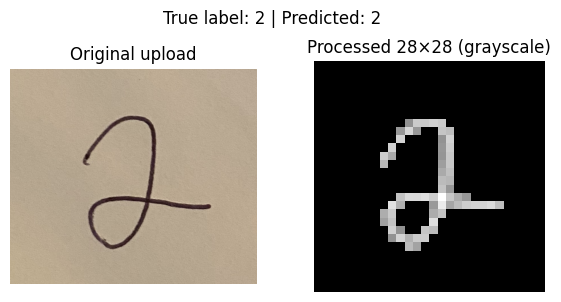

File: 2.png
True label: 2
Predicted label: 2
------------------------------------------------------------


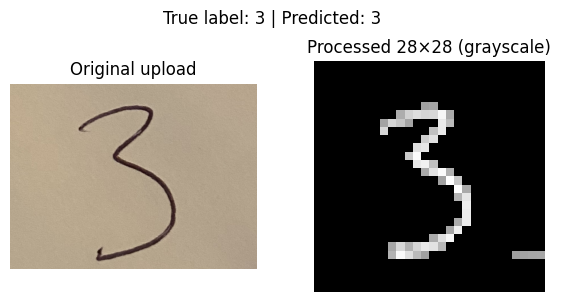

File: 3.png
True label: 3
Predicted label: 3
------------------------------------------------------------


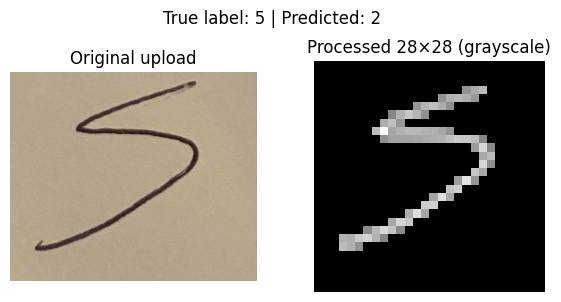

File: 5.png
True label: 5
Predicted label: 2
------------------------------------------------------------


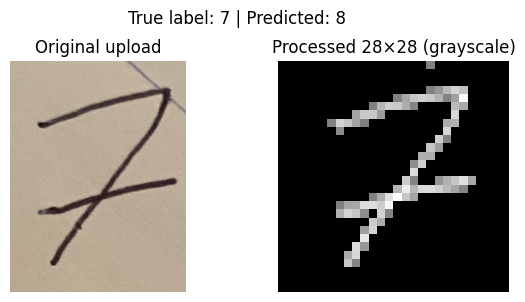

File: 7.png
True label: 7
Predicted label: 8
------------------------------------------------------------


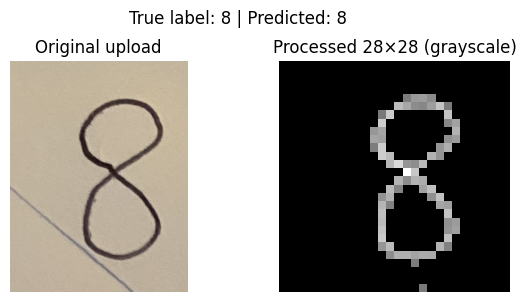

File: 8.png
True label: 8
Predicted label: 8
------------------------------------------------------------


In [ ]:
# Run predictions on all uploaded images
for fname in uploaded.keys():
    try:
        predict_single_image(model, fname)
    except Exception as e:
        print(f"Skipping {fname}: {e}")
